In [1]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from opacus import PrivacyEngine

In [2]:
df = pd.read_csv("Final_Depression3_anonymised.csv")
print("Shape:", df.shape)
df.head()

Shape: (11702, 39)


,education,urban,gender,engnat,screensize,uniquenetworklocation,hand,religion,orientation,race,...,TIPI2,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10,Condition
0,TKN_25ff27d8,TKN_2915511a,Female,No,TKN_f1f2b172,TKN_9134e5db,TKN_92b09c7c,TKN_05b81f76,TKN_6311ae17,TKN_25a81701,...,3,4,7,6,4,6,5,1,2,Extremely Severe
1,TKN_25ff27d8,TKN_2915511a,Female,Yes,TKN_f1f2b172,TKN_9134e5db,TKN_92b09c7c,TKN_05b81f76,TKN_6b76bbae,TKN_25a81701,...,3,5,6,6,3,6,6,2,1,Normal
2,TKN_25ff27d8,TKN_2915511a,Female,No,TKN_ea75e325,TKN_9134e5db,TKN_92b09c7c,TKN_05b81f76,TKN_6b76bbae,TKN_25a81701,...,6,3,3,6,3,7,6,3,1,Moderate
3,TKN_25ff27d8,TKN_2915511a,Female,Yes,TKN_ea75e325,TKN_9134e5db,TKN_92b09c7c,TKN_05b81f76,TKN_6311ae17,TKN_25a81701,...,5,1,7,3,4,3,7,1,2,Extremely Severe
4,TKN_25ff27d8,TKN_2915511a,Female,Yes,TKN_f1f2b172,TKN_9134e5db,TKN_92b09c7c,TKN_05b81f76,TKN_6b76bbae,TKN_25a81701,...,5,2,5,5,4,5,6,2,2,Moderate


In [3]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
label_encoders = {}
target_column = 'Condition'

# Encode all categorical columns except the target
for col in df_encoded.select_dtypes(include='object').columns:
    if col != target_column:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        label_encoders[col] = le

# Encode the target as well
le_target = LabelEncoder()
df_encoded[target_column] = le_target.fit_transform(df_encoded[target_column])

# Now split from df_encoded
X = df_encoded.drop(columns=[target_column])
y = df_encoded[target_column]

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Apply SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)



In [4]:
# Check and encode any remaining non-numeric features
for col in X_train.columns:
    if X_train[col].dtype == 'object' or X_train[col].dtype.name == 'category':
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col])

# Now retry SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)


In [5]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert to PyTorch tensors (make sure all are numeric)
X_train_tensor = torch.tensor(X_train_sm.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_sm, dtype=torch.long)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)



In [6]:
# !pip install diffprivlib
# !pip install imbalanced-learn

In [7]:
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.model(x)

input_dim = X_train.shape[1]
num_classes = len(np.unique(y))
model = MLP(input_dim, num_classes)


In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

privacy_engine = PrivacyEngine()
model, optimizer, train_loader = privacy_engine.make_private(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader,
    noise_multiplier=1.0,
    max_grad_norm=1.0,
)


C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\opacus\privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(


In [9]:
best_val_loss = float('inf')
patience = 25          # Stop after 3 epochs of no improvement
counter = 0
max_epochs = 50       # Max cap in case it doesn't converge

for epoch in range(max_epochs):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Evaluate on validation set
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor).item()

    print(f"Epoch {epoch+1} - Training Loss: {total_loss:.4f} - Validation Loss: {val_loss:.4f}")

    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "trained_mlp_model.pth")  # Save best model
        print("New best model saved!")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping: No improvement for 3 consecutive epochs.")
            break


Epoch 1 - Training Loss: 327.4306 - Validation Loss: 0.9048
New best model saved!
Epoch 2 - Training Loss: 228.5139 - Validation Loss: 0.7058
New best model saved!
Epoch 3 - Training Loss: 202.8047 - Validation Loss: 0.6403
New best model saved!
Epoch 4 - Training Loss: 184.0787 - Validation Loss: 0.6206
New best model saved!
Epoch 5 - Training Loss: 173.4375 - Validation Loss: 0.6233
Epoch 6 - Training Loss: 173.2914 - Validation Loss: 0.6386
Epoch 7 - Training Loss: 176.5639 - Validation Loss: 0.6617
Epoch 8 - Training Loss: 180.4632 - Validation Loss: 0.6854
Epoch 9 - Training Loss: 189.3194 - Validation Loss: 0.7627
Epoch 10 - Training Loss: 187.1003 - Validation Loss: 0.7766
Epoch 11 - Training Loss: 193.4513 - Validation Loss: 0.8577
Epoch 12 - Training Loss: 189.1780 - Validation Loss: 0.8160
Epoch 13 - Training Loss: 192.4121 - Validation Loss: 0.8424
Epoch 14 - Training Loss: 185.4672 - Validation Loss: 0.8448
Epoch 15 - Training Loss: 187.8393 - Validation Loss: 0.8513
Epoch 

In [10]:
model.eval()
with torch.no_grad():
    y_train_pred = model(X_train_tensor).argmax(dim=1)
    y_val_pred = model(X_val_tensor).argmax(dim=1)

train_acc = accuracy_score(y_train_tensor, y_train_pred)
val_acc = accuracy_score(y_val_tensor, y_val_pred)

print(f"\n Training Accuracy: {train_acc:.4f}")
print(f" Validation Accuracy: {val_acc:.4f}\n")

print("Classification Report (Validation):")
print(classification_report(y_val_tensor, y_val_pred, target_names=[str(c) for c in le_target.classes_]))


epsilon = privacy_engine.accountant.get_epsilon(delta=1e-5)
print(f"\n Differential Privacy Epsilon: {epsilon:.2f} (δ=1e-5)")




 Training Accuracy: 0.7964
 Validation Accuracy: 0.7860

Classification Report (Validation):
                  precision    recall  f1-score   support

Extremely Severe       0.93      0.91      0.92       788
            Mild       0.45      0.68      0.54       224
        Moderate       0.74      0.71      0.73       422
          Normal       0.99      0.71      0.83       524
          Severe       0.66      0.77      0.71       383

        accuracy                           0.79      2341
       macro avg       0.75      0.76      0.75      2341
    weighted avg       0.82      0.79      0.79      2341


 Differential Privacy Epsilon: 1.86 (δ=1e-5)


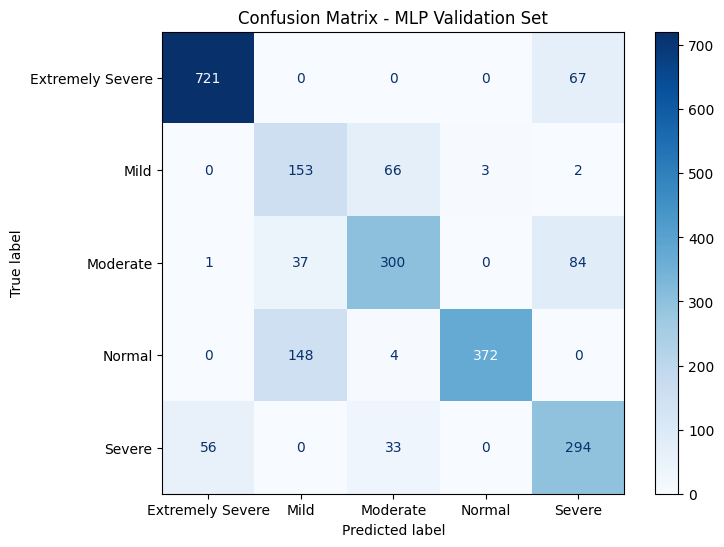

In [11]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# STEP 1: Predict using the trained MLP model
model.eval()
with torch.no_grad():
    y_val_logits = model(X_val_tensor)
    y_val_pred = torch.argmax(y_val_logits, dim=1).cpu().numpy()

# STEP 2: Optional - decode integer labels to original class names if you used LabelEncoder
class_labels = [str(cls) for cls in le_target.classes_]  # Converts int64 to string labels

# STEP 3: Generate the confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

# STEP 4: Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Confusion Matrix - MLP Validation Set")
plt.show()


In [12]:
# Run in terminal or ! in Jupyter
!pip install tenseal

In [13]:
import tenseal as ts
import numpy as np
import torch

In [14]:
import tenseal as ts
print(ts.__version__)


0.3.16


In [15]:
# Simulate a dummy gradient from a layer (e.g., 5 parameters)
local_gradient = torch.tensor([0.25, -0.3, 0.1, 0.55, -0.12], dtype=torch.float32)

print("Original Gradient (Local Model):")
print(local_gradient.numpy())


Original Gradient (Local Model):
[ 0.25 -0.3   0.1   0.55 -0.12]


In [16]:
# CKKS encryption context setup
context = ts.context(
    ts.SCHEME_TYPE.CKKS,
    poly_modulus_degree=8192,
    coeff_mod_bit_sizes=[60, 40, 40, 60]
)
context.generate_galois_keys()
context.global_scale = 2**40

# Save public & secret key (just for simulation; normally private key stays secure)
public_context = context.copy()  # This is what would be shared with the server
public_context.make_context_public()  # Only allows encryption
with open("context.ser", "wb") as f:
    f.write(public_context.serialize())

In [17]:
import torch

# Set device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [18]:
def encrypt_gradients_from_model(model, X_batch, y_batch, loss_fn, context):
    model.train()
    model.zero_grad()

    outputs = model(X_batch)
    loss = loss_fn(outputs, y_batch)
    loss.backward()

    encrypted_grads = {}

    for name, param in model.named_parameters():
        if param.requires_grad and param.grad is not None:
            grad = param.grad.view(-1).detach().cpu().numpy()
            enc_grad = ts.ckks_vector(context, grad.tolist())
            encrypted_grads[name] = enc_grad

            print(f"\n Layer: {name}")
            print(f"   Original Gradient Sample: {grad[:5]}")
            print(f"   Encrypted Gradient Sample (decrypted view): {enc_grad.decrypt()[:5]}")

    return encrypted_grads

In [19]:
import torch.nn as nn

loss_fn = nn.CrossEntropyLoss()

# Get one batch from your train loader
X_sample, y_sample = next(iter(train_loader))
X_sample, y_sample = X_sample.to(device), y_sample.to(device)

# Run encryption on gradients
encrypted_grads = encrypt_gradients_from_model(model, X_sample, y_sample, loss_fn, context)


The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.

 Layer: _module.model.0.weight
   Original Gradient Sample: [ 0.01608374  0.00254438  0.00076464 -0.00222693 -0.00335413]
   Encrypted Gradient Sample (decrypted view): [0.016083733577911777, 0.0025443806591633478, 0.0007646425799624282, -0.0022269324970929164, -0.0033541248167024973]

 Layer: _module.model.0.bias
   Original Gradient Sample: [ 0.00459263 -0.00616678 -0.00173313  0.          0.        ]
   Encrypted Gradient Sample (decrypted view): [0.004592628869243882, -0.006166783596446048, -0.0017331294719091373, 2.8036082898594055e-10, -3.5725645090622524e-10]
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.

 Layer: _mo

In [20]:
import torch
import tenseal as ts
import pickle
import requests
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# -------------------------------
# CKKS Setup
# -------------------------------
def get_ckks_context():
    context = ts.context(
        ts.SCHEME_TYPE.CKKS,
        poly_modulus_degree=8192,
        coeff_mod_bit_sizes=[60, 40, 40, 60]
    )
    context.global_scale = 2**40
    context.generate_galois_keys()
    return context

ckks_context = get_ckks_context()
public_context = ckks_context.serialize(save_secret_key=False)

# -------------------------------
# Gradient Flattening
# -------------------------------
def flatten_gradients(model):
    grads = []
    for param in model.parameters():
        if param.grad is not None:
            grads.append(param.grad.view(-1).cpu())
    flat = torch.cat(grads)
    print(f"[DEBUG] Flattened gradient length: {len(flat)}")
    return flat

# -------------------------------
# Encrypt Gradients with CKKS
# -------------------------------
def encrypt_gradients(flattened_grads, context, chunk_size=8000):
    if len(flattened_grads) > chunk_size:
        print("[WARNING] Gradient too large for single CKKS vector (>8192). Chunking.")
        chunks = torch.chunk(flattened_grads, (len(flattened_grads) + chunk_size - 1) // chunk_size)
    else:
        chunks = [flattened_grads]

    encrypted_chunks = []
    ctx = ts.context_from(context)
    ctx.make_context_public()

    for i, chunk in enumerate(chunks):
        enc = ts.ckks_vector(ctx, chunk.tolist())
        encrypted_chunks.append(enc)
        print(f"[DEBUG] Encrypted chunk {i} with {len(chunk)} values")

    return encrypted_chunks

# -------------------------------
# Send Encrypted Chunks to Server
# -------------------------------
def send_encrypted_chunks_binary(encrypted_chunks, server_url, client_id="hospital_3"):
    for i, enc_chunk in enumerate(encrypted_chunks):
        try:
            payload = {
                'chunk_id': i,
                'client_id': client_id,  
                'data': enc_chunk.serialize()
            }
            data = pickle.dumps(payload)

            response = requests.post(
                server_url,
                data=data,
                headers={'Content-Type': 'application/octet-stream'},
                verify=False  
            )
            if response.status_code == 200:
                print(f"[CLIENT] Sent chunk {i} ({len(data)} bytes)")
            else:
                print(f"[CLIENT] Failed to send chunk {i}: HTTP {response.status_code}")
        except Exception as e:
            print(f"[CLIENT] Error sending chunk {i}: {e}")


# -------------------------------
# Client Main Routine
# -------------------------------
def run_client_post_training(model):
    print("[CLIENT] Preparing gradients...")
    grads = flatten_gradients(model)
    enc_chunks = encrypt_gradients(grads, public_context)

    print("[CLIENT] Sending encrypted gradients...")
    send_encrypted_chunks_binary(enc_chunks, server_url="https://127.0.0.1:5055")
    
run_client_post_training(model)


[CLIENT] Preparing gradients...
[DEBUG] Flattened gradient length: 13573
[WARNING] Gradient too large for single CKKS vector (>8192). Chunking.
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.
[DEBUG] Encrypted chunk 0 with 6787 values
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.
[DEBUG] Encrypted chunk 1 with 6786 values
[CLIENT] Sending encrypted gradients...


C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '127.0.0.1'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


[CLIENT] Sent chunk 0 (668071 bytes)
[CLIENT] Sent chunk 1 (668418 bytes)


C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '127.0.0.1'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [21]:
import torch
import torch.nn as nn
import pickle
import tenseal as ts
from sklearn.metrics import classification_report
import warnings
import os
import shutil
import requests

warnings.filterwarnings("ignore", category=UserWarning)

# -------------------------------
# Define MLP Architecture
# -------------------------------
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim1=128, hidden_dim2=64, output_dim=5):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, output_dim)
        )

    def forward(self, x):
        return self.model(x)

# -------------------------------
# Decrypt + Apply Global Gradient
# -------------------------------
def receive_and_update_model(model, ckks_context, global_gradient_file="aggregated_gradient_global_encrypted.pkl"):
    with open(global_gradient_file, "rb") as f:
        encrypted_chunks_serialized = pickle.load(f)

    decrypted_flattened_grad = []
    for i, chunk_ser in enumerate(encrypted_chunks_serialized):
        enc_chunk = ts.ckks_vector_from(ckks_context, chunk_ser)
        decrypted_chunk = torch.tensor(enc_chunk.decrypt(), dtype=torch.float32)
        decrypted_flattened_grad.append(decrypted_chunk)
        print(f"[CLIENT] Decrypted chunk {i} of size {len(decrypted_chunk)}")

    decrypted_gradient = torch.cat(decrypted_flattened_grad)
    print(f"[CLIENT] Total decrypted global gradient length: {len(decrypted_gradient)}")

    # Clip gradient norm if necessary
    grad_norm = decrypted_gradient.norm()
    if grad_norm > 1e2:
        decrypted_gradient = decrypted_gradient / grad_norm * 1e2
        print(f"[CLIENT] Gradient clipped to norm 1e2 (original norm: {grad_norm:.2e})")

    # Apply gradients to model
    pointer = 0
    for param in model.parameters():
        if param.grad is not None:
            param_shape = param.grad.shape
            param_size = param.grad.numel()
            grad_slice = decrypted_gradient[pointer:pointer + param_size].view(param_shape)
            param.data -= grad_slice
            pointer += param_size

    print("[CLIENT] Global model updated with aggregated global gradient")

# -------------------------------
# Evaluate Model
# -------------------------------
def evaluate_model(model, dataloader, criterion, split_name="Validation"):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    acc = 100.0 * correct / total
    print(f"[CLIENT] {split_name} → Accuracy: {acc:.2f}%, Loss: {total_loss:.4f}")
    return all_preds, all_labels, total_loss

# -------------------------------
# HE Gradient Send Helpers
# -------------------------------
def flatten_gradients(model):
    grads = []
    for param in model.parameters():
        if param.grad is not None:
            grads.append(param.grad.view(-1).cpu())
    flat = torch.cat(grads)
    return flat

def encrypt_gradients(flattened_grads, context, chunk_size=8000):
    chunks = torch.chunk(flattened_grads, (len(flattened_grads) + chunk_size - 1) // chunk_size)
    encrypted_chunks = []
    ctx = ts.context_from(context)
    ctx.make_context_public()

    for i, chunk in enumerate(chunks):
        enc = ts.ckks_vector(ctx, chunk.tolist())
        encrypted_chunks.append(enc)
        print(f"[DEBUG] Encrypted chunk {i} with {len(chunk)} values")
    return encrypted_chunks

def send_encrypted_chunks_binary(encrypted_chunks, server_url, client_id="hospital_3"):
    for i, enc_chunk in enumerate(encrypted_chunks):
        try:
            payload = {
                'chunk_id': i,
                'client_id': client_id,
                'data': enc_chunk.serialize()
            }
            data = pickle.dumps(payload)
            response = requests.post(
                server_url,
                data=data,
                headers={'Content-Type': 'application/octet-stream'},
                verify=False
            )
            if response.status_code == 200:
                print(f"[CLIENT] Sent chunk {i} ({len(data)} bytes)")
            else:
                print(f"[CLIENT] Failed to send chunk {i}: HTTP {response.status_code}")
        except Exception as e:
            print(f"[CLIENT] Error sending chunk {i}: {e}")

# -------------------------------
# Main Federated Loop 
# -------------------------------
ckks_context = ts.context(ts.SCHEME_TYPE.CKKS, poly_modulus_degree=8192, coeff_mod_bit_sizes=[60, 40, 40, 60])
ckks_context.global_scale = 2**40
ckks_context.generate_galois_keys()
public_context = ckks_context.serialize(save_secret_key=False)

# Init model
sample_batch, _ = next(iter(train_loader))
input_dim = sample_batch.shape[1]
global_model = MLP(input_dim=input_dim, output_dim=5)
state_dict = torch.load("trained_mlp_model.pth")
fixed_state_dict = {k.replace("_module.", ""): v for k, v in state_dict.items()}
global_model.load_state_dict(fixed_state_dict, strict=False)
print("[CLIENT] Loaded local model weights from 'trained_mlp_model.pth'")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(global_model.parameters(), lr=0.01)

best_val_loss = float('inf')
patience = 3
counter = 0
max_rounds = 50

for round in range(max_rounds):
    print(f"\n === Federated Round {round+1} ===")

    # STEP 1: Local training
    global_model.train()
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = global_model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    # STEP 2: Wait for global gradient
    user_in = input("Press Enter once server has aggregated and saved encrypted global gradient (or type 'exit'): ").strip().lower()
    if user_in == "exit":
        print(" Exiting federated training loop.")
        break

    # STEP 3: Apply global gradient
    receive_and_update_model(global_model, ckks_context)

    # STEP 4: Re-train model (after update)
    global_model.train()
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = global_model(x_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    # STEP 5: Send new gradients
    print("[CLIENT] Encrypting & sending updated gradients...")
    grads = flatten_gradients(global_model)
    encrypted_chunks = encrypt_gradients(grads, public_context)
    send_encrypted_chunks_binary(encrypted_chunks, server_url="https://127.0.0.1:5055", client_id="hospital_3")

    # STEP 6: Evaluation
    evaluate_model(global_model, train_loader, criterion, "Training")
    val_preds, val_labels, val_loss = evaluate_model(global_model, val_loader, criterion, "Validation")
    print("[CLIENT] Validation Classification Report:")
    print(classification_report(val_labels, val_preds, zero_division=0))

    # STEP 7: Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(global_model.state_dict(), "trained_global_model_3.pth")
        print("Best model saved.")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping.")
            break

    # STEP 8: Cleanup Aggregated Files
    try:
        if os.path.exists("aggregated_gradient_global_encrypted.pkl"):
            os.remove("aggregated_gradient_global_encrypted.pkl")
            print("[CLIENT] 🧹 Deleted 'aggregated_gradient_global_encrypted.pkl'")
        if os.path.exists("aggregated_chunks_bin"):
            
            shutil.rmtree("aggregated_chunks_bin")
            print("[CLIENT] Deleted 'aggregated_chunks_bin' folder")
    except Exception as e:
        print(f"[CLIENT] Cleanup failed: {e}")


[CLIENT] Loaded local model weights from 'trained_mlp_model.pth'

 === Federated Round 1 ===


Press Enter once server has aggregated and saved encrypted global gradient (or type 'exit'):  


[CLIENT] Decrypted chunk 0 of size 6787
[CLIENT] Decrypted chunk 1 of size 6786
[CLIENT] Total decrypted global gradient length: 13573
[CLIENT] Gradient clipped to norm 1e2 (original norm: inf)
[CLIENT] Global model updated with aggregated global gradient
[CLIENT] Encrypting & sending updated gradients...
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.
[DEBUG] Encrypted chunk 0 with 6787 values
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.
[DEBUG] Encrypted chunk 1 with 6786 values


C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '127.0.0.1'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


[CLIENT] Sent chunk 0 (668430 bytes)


...

[CLIENT] Decrypted chunk 0 of size 6787
[CLIENT] Decrypted chunk 1 of size 6786
[CLIENT] Total decrypted global gradient length: 13573
[CLIENT] Gradient clipped to norm 1e2 (original norm: inf)
[CLIENT] Global model updated with aggregated global gradient
[CLIENT] Encrypting & sending updated gradients...
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.
[DEBUG] Encrypted chunk 0 with 6787 values
The following operations are disabled in this setup: matmul, matmul_plain, enc_matmul_plain, conv2d_im2col.
If you need to use those operations, try increasing the poly_modulus parameter, to fit your input.
[DEBUG] Encrypted chunk 1 with 6786 values


C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '127.0.0.1'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


[CLIENT] Sent chunk 0 (667782 bytes)


C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host '127.0.0.1'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


[CLIENT] Sent chunk 1 (668514 bytes)
[CLIENT] Training → Accuracy: 69.52%, Loss: 167.2214
[CLIENT] Validation → Accuracy: 67.88%, Loss: 27.8084
[CLIENT] Validation Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.99      0.88       788
           1       0.29      0.38      0.33       224
           2       0.60      0.57      0.58       422
           3       1.00      0.57      0.73       524
           4       0.50      0.47      0.49       383

    accuracy                           0.68      2341
   macro avg       0.64      0.60      0.60      2341
weighted avg       0.71      0.68      0.68      2341

Early stopping.
